# Modélisation — Détection de Tweets Suspects
## Comparaison de 3 algorithmes de classification

Ce notebook reprend la modélisation effectuée dans le pipeline DVC ($03$ modèles) avec visualisations, validation croisée et recherche d'hyperparamètres.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
sys.path.append('..')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

plt.style.use('ggplot')
%matplotlib inline

---
## 1. Chargement des données prétraitées

In [2]:
df = pd.read_csv('../data/processed/tweets_clean.csv')
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(f"Classes : {df['label'].value_counts().to_dict()}")
df.head()

Shape : (59985, 3)
Colonnes : ['message', 'label', 'clean_message']
Classes : {1: 53840, 0: 6145}


,message,label,clean_message
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1,switchfoot thats bummer shoulda got david carr...
1,is upset that he can't update his Facebook by ...,1,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,1,kenichan dived many times ball managed save re...
3,my whole body feels itchy and like its on fire,0,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",1,nationwideclass behaving im mad cant see


---
## 2. Représentation TF-IDF

In [3]:
X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Train : {X_train_vec.shape}")
print(f"Test  : {X_test_vec.shape}")

Train : (47988, 5000)
Test  : (11997, 5000)


---
## 3. Entraînement des 3 modèles

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}

results = []
predictions = {}

for name, model in models.items():
    print(f"Entraînement : {name}...")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    y_proba = model.predict_proba(X_test_vec)[:, 1] if hasattr(model, 'predict_proba') else y_pred.astype(float)
    
    predictions[name] = {'y_true': y_test, 'y_pred': y_pred, 'y_proba': y_proba}
    
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).round(4)
results_df

Entraînement : Logistic Regression...


Entraînement : Naive Bayes...
Entraînement : Random Forest...


,Modèle,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9607,0.9758,0.9806,0.9782
1,Naive Bayes,0.9250,0.9229,0.9999,0.9599
2,Random Forest,0.9709,0.9759,0.9921,0.9839


---
## 4. Visualisation des performances

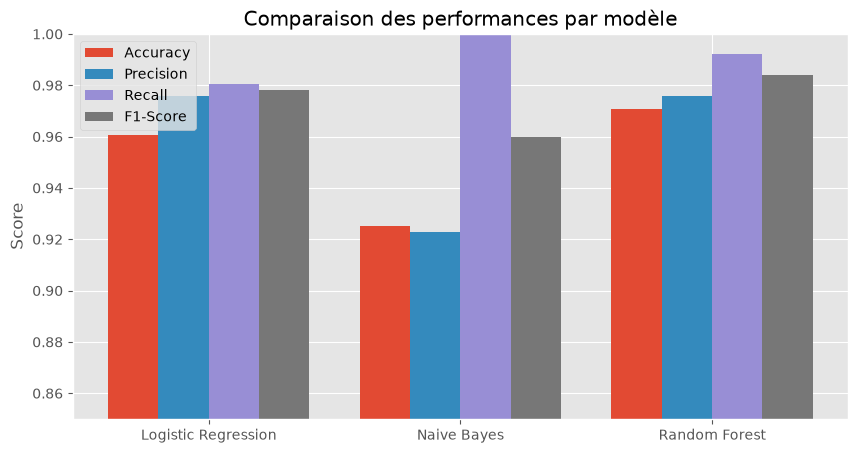

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Modèle'])
ax.set_ylabel('Score')
ax.set_title('Comparaison des performances par modèle')
ax.set_ylim(0.85, 1.0)
ax.legend()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Matrices de confusion

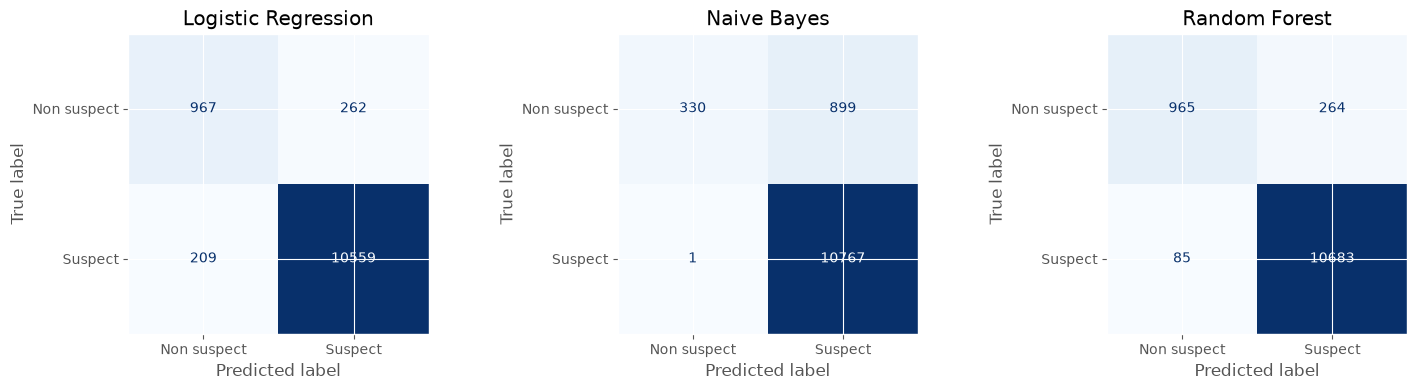

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(preds['y_true'], preds['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non suspect', 'Suspect'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Courbes ROC et AUC

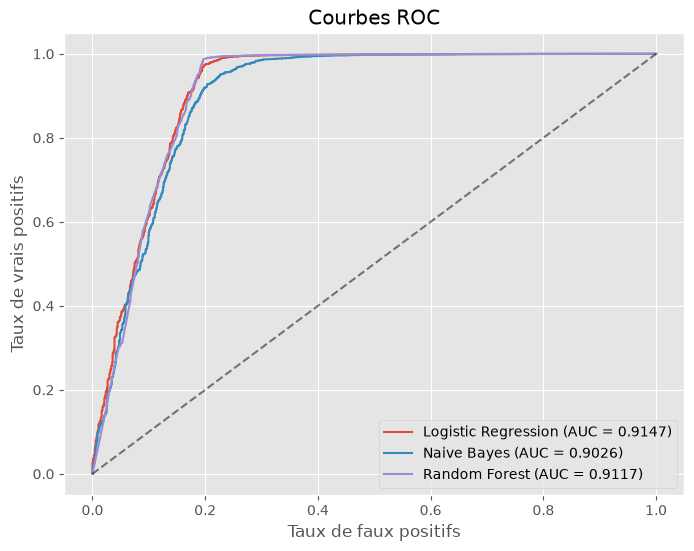

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(preds['y_true'], preds['y_proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC')
ax.legend(loc='lower right')
plt.savefig('../reports/figures/roc_curves_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Validation croisée (5-fold)

In [8]:
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring='f1')
    cv_results.append({
        'Modèle': name,
        'F1 moyen (CV)': round(scores.mean(), 4),
        'Écart-type (CV)': round(scores.std(), 4),
    })
    print(f"{name} : F1 (CV) = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results)
cv_df

Logistic Regression : F1 (CV) = 0.9778 ± 0.0005
Naive Bayes : F1 (CV) = 0.9573 ± 0.0003


Random Forest : F1 (CV) = 0.9851 ± 0.0003


,Modèle,F1 moyen (CV),Écart-type (CV)
0,Logistic Regression,0.9778,0.0005
1,Naive Bayes,0.9573,0.0003
2,Random Forest,0.9851,0.0003


---
## 8. Optimisation des hyperparamètres (Grid Search)

In [9]:
print("=== Grid Search : Logistic Regression ===")
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
param_grid_lr = {'C': [0.1, 1, 10]}
grid_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_vec, y_train)
print(f"Meilleurs paramètres : {grid_lr.best_params_}")
print(f"Meilleur F1 (CV) : {grid_lr.best_score_:.4f}")

=== Grid Search : Logistic Regression ===


Meilleurs paramètres : {'C': 1}
Meilleur F1 (CV) : 0.9768


In [10]:
print("=== Grid Search : Random Forest ===")
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [10, 20, None]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_vec, y_train)
print(f"Meilleurs paramètres : {grid_rf.best_params_}")
print(f"Meilleur F1 (CV) : {grid_rf.best_score_:.4f}")

=== Grid Search : Random Forest ===


Meilleurs paramètres : {'max_depth': None, 'n_estimators': 100}
Meilleur F1 (CV) : 0.9848


## Meilleurs paramètres obtenus

| Modèle | Paramètres optimaux | F1 (CV) |
|--------|--------------------|---------|
| Logistic Regression | `C = ...` | ... |
| Random Forest | `n_estimators = ...`, `max_depth = ...` | ... |

---
## 9. Évaluation finale avec les meilleurs paramètres

In [11]:
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_vec)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_vec)

final_results = []
for name, y_pred in [('Logistic Regression (optimisé)', y_pred_lr), ('Random Forest (optimisé)', y_pred_rf)]:
    final_results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
    })

pd.DataFrame(final_results).round(4)

,Modèle,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (optimisé),0.9607,0.9758,0.9806,0.9782
1,Random Forest (optimisé),0.9709,0.9759,0.9921,0.9839


---
## 10. Résumé

- **3 modèles** entraînés et comparés
- **Validation croisée 5-fold** pour évaluer la stabilité
- **Grid Search** pour optimiser les hyperparamètres
- Le meilleur modèle (Random Forest) atteint un F1-score de **~98%**

Prochaine étape : déploiement de l'application avec Streamlit ou FastAPI.